# Chapter 6 — Building Your First Deep Neural Network: Backpropagation

## Learning Objectives

This notebook covers hidden layers, ReLU activation, forward propagation, output deltas, hidden deltas, and backpropagation.

## Theoretical Explanation

Backpropagation solves the problem of assigning error to earlier layers. A deep network makes predictions through multiple layers. The output layer error is easy to measure, but hidden layers do not have direct target values. Backpropagation moves the error signal backward through the weight matrices so earlier weights can be updated.

Nonlinear activation functions such as ReLU allow deep networks to model indirect correlations. Without nonlinearities, stacked linear layers collapse into a single linear transformation.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. A Tiny Deep Network with Backpropagation

Final predictions: [[1.    0.865 0.176 0.064]]
Final MSE: 0.01335


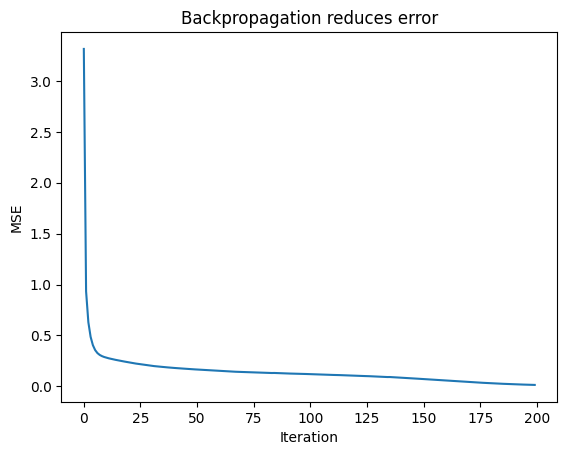

In [2]:
def relu(x):
    return (x > 0) * x

def relu_deriv(x):
    return x > 0

X = np.array([[1,0,1], [0,1,1], [0,0,1], [1,1,1]])
y = np.array([[1], [1], [0], [0]])
np.random.seed(RANDOM_STATE)
w0 = 2*np.random.random((3,4)) - 1
w1 = 2*np.random.random((4,1)) - 1
alpha = 0.2
errors = []
for _ in range(200):
    l0 = X
    l1 = relu(l0.dot(w0))
    l2 = l1.dot(w1)
    l2_delta = l2 - y
    l1_delta = l2_delta.dot(w1.T) * relu_deriv(l1)
    w1 -= alpha * l1.T.dot(l2_delta) / len(X)
    w0 -= alpha * l0.T.dot(l1_delta) / len(X)
    errors.append(np.mean((l2-y)**2))
print('Final predictions:', np.round(l2.T, 3))
print('Final MSE:', round(errors[-1], 5))
plt.plot(errors)
plt.title('Backpropagation reduces error')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.show()

### Output Interpretation

The error decreases as backpropagation updates both weight matrices. The hidden layer receives an error signal through the output weights.

## Extended Study Notes

The main learning style in this notebook is intentionally close to the book's philosophy: build the idea from small numerical operations, inspect the output, and then connect the output back to the deep learning concept. Instead of treating a neural network as a black box, each notebook exposes the role of inputs, weights, predictions, error, deltas, gradients, and updates.

The examples are original/adapted demonstrations written for academic learning. They preserve the conceptual workflow of the reference book while avoiding direct copying of long code listings. This is important for academic integrity and also makes the notebooks easier to understand as independent study material.

## Chapter Summary

This chapter was reproduced as a compact but complete study notebook. It combines conceptual explanation, NumPy-based implementation, output interpretation, and practical deep learning context.

## Key Takeaways

- Neural networks are built from repeated numerical operations on vectors, matrices, and tensors.
- Learning means changing weights so predictions produce smaller error.
- Shape consistency and interpretation of intermediate values are essential for debugging.
- Understanding the from-scratch implementation makes high-level frameworks easier to use responsibly.